# Phase 1 — Exploratory Data Analysis (EDA)
### UNSW-NB15 — Raw Files (UNSW-NB15_1..4.csv)

**~2.54 M records · 49 features · 4 raw CSV files (no header)**

## 1.0 — Setup & Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier

BASE    = r'c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15'
OUT_EDA = os.path.join(BASE, 'outputs', 'eda')
os.makedirs(OUT_EDA, exist_ok=True)

# 49 column names from NUSW-NB15_features.csv
COLUMNS = [
    'srcip','sport','dstip','dsport','proto','state',
    'dur','sbytes','dbytes','sttl','dttl','sloss','dloss',
    'service','Sload','Dload','Spkts','Dpkts',
    'swin','dwin','stcpb','dtcpb','smeansz','dmeansz',
    'trans_depth','res_bdy_len','Sjit','Djit',
    'Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd',
    'is_ftp_login','ct_ftp_cmd',
    'ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'attack_cat','label'
]

# Columns used for numeric analysis (exclude IPs, timestamps, targets)
EXCL     = {'srcip','dstip','attack_cat','label','Stime','Ltime'}
NUM_COLS = [c for c in COLUMNS if c not in EXCL]

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Setup complete — output dir:', OUT_EDA)
print('Analysis feature columns  :', len(NUM_COLS))


Setup complete — output dir: c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\eda
Analysis feature columns  : 43


## 1.1 — Load Raw Files & Apply Schema

In [5]:
file_stats = []
dfs = []

for i in range(1, 5):
    path = os.path.join(BASE, f'UNSW-NB15_{i}.csv')
    df_i = pd.read_csv(path, header=None, names=COLUMNS,
                       encoding='latin1', low_memory=False)
    # Fix UTF-8 BOM that appears in file 1's srcip
    df_i['srcip'] = (df_i['srcip'].astype(str)
                     .str.replace('\ufeff', '', regex=False).str.strip())
    # Normalise attack_cat: strip whitespace, merge Backdoor/Backdoors, fill any remaining NaN
    df_i['attack_cat'] = (df_i['attack_cat'].astype(str).str.strip()
                          .replace({'nan': 'Normal', '': 'Normal', 'Backdoors': 'Backdoor'})
                          .fillna('Normal'))
    df_i['label'] = pd.to_numeric(df_i['label'], errors='coerce').fillna(0).astype(int)

    n_total  = len(df_i)
    n_normal = (df_i['label'] == 0).sum()
    n_attack = (df_i['label'] == 1).sum()
    file_stats.append({'file': f'UNSW-NB15_{i}.csv',
                       'total': n_total, 'normal': n_normal, 'attack': n_attack})
    print(f'File {i}: {n_total:>9,} rows  |  normal={n_normal:>9,}  |  attack={n_attack:>7,}')
    dfs.append(df_i)

df = pd.concat(dfs, ignore_index=True)
# Ensure no NaN survived concat (pandas 3.0 can reintroduce them)
df['attack_cat'] = df['attack_cat'].fillna('Normal')

attack_cats = sorted(c for c in df['attack_cat'].unique() if c != 'Normal')
print(f'\nCombined : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Attack categories ({len(attack_cats)}): {attack_cats}')
print(f'(+ Normal flows labelled as "Normal" in attack_cat)')


File 1:   700,001 rows  |  normal=  677,786  |  attack= 22,215
File 2:   700,001 rows  |  normal=  647,252  |  attack= 52,749
File 3:   700,001 rows  |  normal=  542,576  |  attack=157,425
File 4:   440,044 rows  |  normal=  351,150  |  attack= 88,894

Combined : 2,540,047 rows x 49 cols
Attack categories (9): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']
(+ Normal flows labelled as "Normal" in attack_cat)


In [6]:
stats_df = pd.DataFrame(file_stats)
stats_df['attack_%'] = (stats_df['attack'] / stats_df['total'] * 100).round(2)
print(stats_df.to_string(index=False))


           file  total  normal  attack  attack_%
UNSW-NB15_1.csv 700001  677786   22215      3.17
UNSW-NB15_2.csv 700001  647252   52749      7.54
UNSW-NB15_3.csv 700001  542576  157425     22.49
UNSW-NB15_4.csv 440044  351150   88894     20.20


In [7]:
info = pd.DataFrame({
    'dtype'     : df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().sum() / len(df) * 100).round(3),
    'unique'    : df.nunique(),
})
print(info.to_string())


                    dtype  null_count  null_%   unique
srcip                 str           0   0.000       44
sport              object           0   0.000   129124
dstip                 str           0   0.000       47
dsport                str           0   0.000    64630
proto                 str           0   0.000      135
state                 str           0   0.000       16
dur               float64           0   0.000   587303
sbytes              int64           0   0.000    14155
dbytes              int64           0   0.000    19166
sttl                int64           0   0.000       13
dttl                int64           0   0.000       11
sloss               int64           0   0.000      544
dloss               int64           0   0.000      707
service               str           0   0.000       13
Sload             float64           0   0.000  1100258
Dload             float64           0   0.000  1173739
Spkts               int64           0   0.000      933
Dpkts     

In [8]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups:,}  ({dups / len(df) * 100:.3f}%)')


Duplicate rows: 480,632  (18.922%)


## 1.2 — Target Distribution (Class Imbalance)

In [9]:
bin_vc    = df['label'].value_counts().rename({0: 'Normal', 1: 'Attack'})
bin_pct   = (bin_vc / len(df) * 100).round(2)
imb_ratio = bin_vc['Normal'] / bin_vc['Attack']
print('=== Binary Label ===')
print(pd.DataFrame({'Count': bin_vc, '%': bin_pct}))
print(f'\nImbalance ratio (Normal:Attack) = {imb_ratio:.2f}:1')


=== Binary Label ===
          Count      %
label                 
Normal  2218764  87.35
Attack   321283  12.65

Imbalance ratio (Normal:Attack) = 6.91:1


In [10]:
cat_vc  = df['attack_cat'].value_counts()
cat_pct = (cat_vc / len(df) * 100).round(3)
print('=== Attack Category Distribution ===')
print(pd.DataFrame({'Count': cat_vc, '%': cat_pct}).to_string())


=== Attack Category Distribution ===
                  Count       %
attack_cat                     
Normal          2218764  87.351
Generic          215481   8.483
Exploits          44525   1.753
Fuzzers           24246   0.955
DoS               16353   0.644
Reconnaissance    13987   0.551
Analysis           2677   0.105
Backdoor           2329   0.092
Shellcode          1511   0.059
Worms               174   0.007


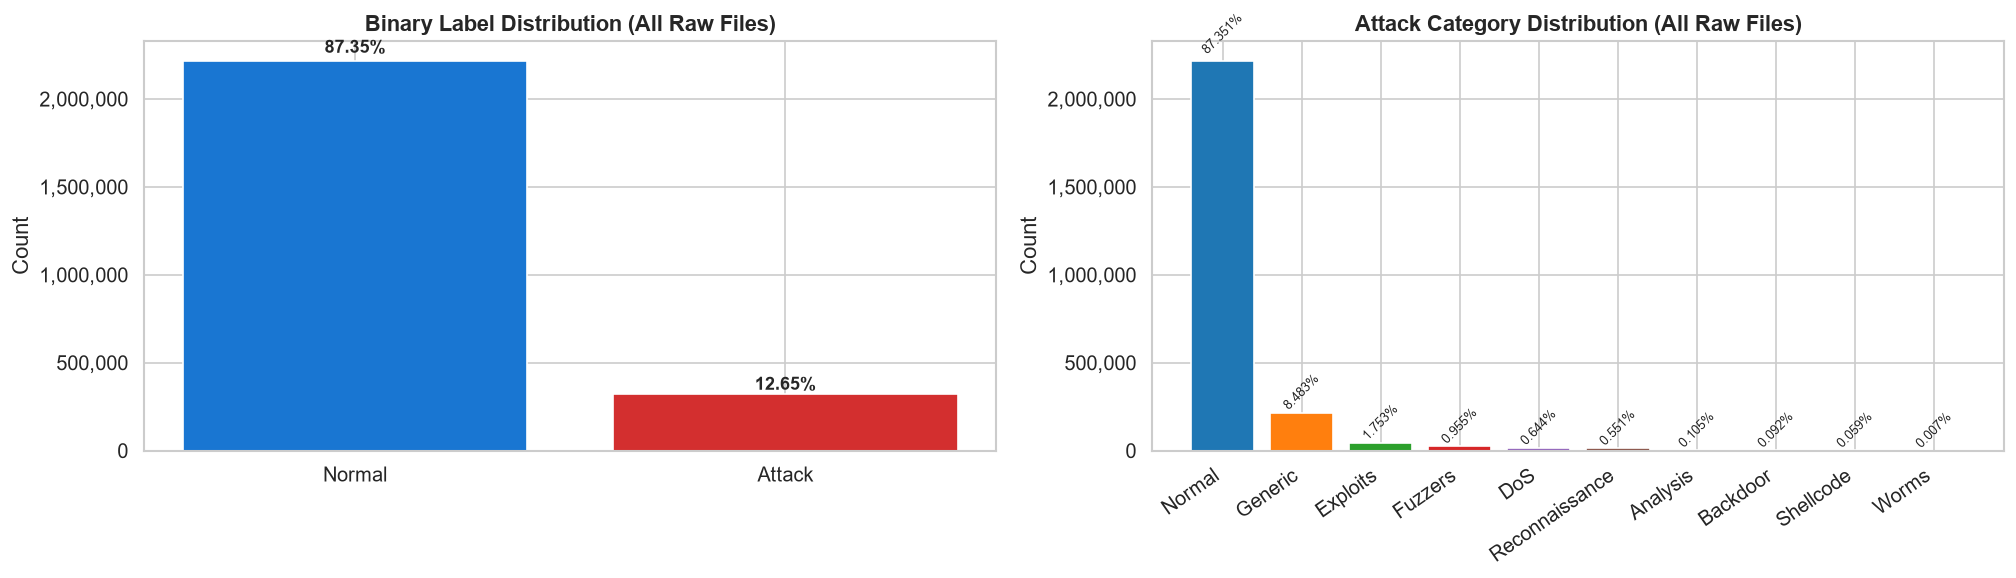

Saved -> class_dist.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
bars = ax.bar(bin_vc.index, bin_vc.values,
              color=['#1976D2','#D32F2F'], edgecolor='white')
for bar, pct in zip(bars, bin_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Binary Label Distribution (All Raw Files)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax2 = axes[1]
pal  = sns.color_palette('tab10', n_colors=len(cat_vc))
bars2 = ax2.bar(cat_vc.index, cat_vc.values, color=pal, edgecolor='white')
for bar, pct in zip(bars2, cat_pct.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
             f'{pct}%', ha='center', va='bottom', fontsize=8, rotation=45)
ax2.set_title('Attack Category Distribution (All Raw Files)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_xticklabels(cat_vc.index, rotation=35, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'class_dist.png'), bbox_inches='tight')
plt.show()
print('Saved -> class_dist.png')


## 1.3 — Feature Statistics & Correlation

In [12]:
num_df    = df[NUM_COLS].select_dtypes(include=np.number)
num_feats = num_df.columns.tolist()
print(f'Numeric feature columns: {len(num_feats)}')

desc = num_df.describe().T
desc['skewness']  = num_df.skew()
desc['kurtosis']  = num_df.kurtosis()
desc['zero_frac'] = (num_df == 0).mean().round(3)
print(desc.sort_values('skewness', ascending=False).head(20).to_string())


Numeric feature columns: 37
                      count          mean           std  min            25%            50%           75%           max    skewness       kurtosis  zero_frac
dur               2540047.0  6.587916e-01  1.392493e+01  0.0       0.001037       0.015861  2.145545e-01  8.786638e+03  590.036391  371440.470936      0.003
trans_depth       2540047.0  8.325318e-02  3.500045e-01  0.0       0.000000       0.000000  0.000000e+00  1.720000e+02  148.640991   65406.520164      0.919
sbytes            2540047.0  4.339600e+03  5.640599e+04  0.0     200.000000    1470.000000  3.182000e+03  1.435577e+07  142.981858   24006.582106      0.000
sloss             2540047.0  5.163921e+00  2.251707e+01  0.0       0.000000       3.000000  7.000000e+00  5.319000e+03  118.739427   18653.410296      0.412
Djit              2540047.0  7.300755e+02  3.438558e+03  0.0       0.000000       2.653561  6.350857e+01  7.812211e+05   98.448415   19088.917383      0.354
Sjit              2540047.0  1

In [13]:
zv = df[num_feats].std()
zero_var_feats = zv[zv == 0].index.tolist()
print(f'Zero-variance features ({len(zero_var_feats)}): {zero_var_feats}')

high_skew = df[num_feats].skew().abs()
high_skew = high_skew[high_skew > 5].sort_values(ascending=False)
print(f'\nHighly skewed (|skew|>5): {len(high_skew)}')
print(high_skew.to_string())


Zero-variance features (0): []

Highly skewed (|skew|>5): 20
dur                 590.036391
trans_depth         148.640991
sbytes              142.981858
sloss               118.739427
Djit                 98.448415
Sjit                 47.651534
ackdat               42.821570
synack               40.538344
tcprtt               32.556720
Spkts                27.084605
Dintpkt              25.186158
is_sm_ips_ports      24.545800
res_bdy_len          18.926613
Sintpkt              18.733592
ct_flw_http_mthd     11.450605
dloss                 9.428584
dbytes                9.089084
Dpkts                 8.484065
Sload                 7.525025
is_ftp_login          5.463226


In [14]:
# Correlation on 50k sample for speed
sample_corr = df[num_feats].sample(50_000, random_state=42).corr().abs()
upper = sample_corr.where(np.triu(np.ones(sample_corr.shape), k=1).astype(bool))
high_corr_df = pd.DataFrame([
    {'Feature_A': c, 'Feature_B': r, 'r': upper.loc[r, c]}
    for c in upper.columns for r in upper.index if upper.loc[r, c] > 0.95
]).sort_values('r', ascending=False)
print(f'High-correlation pairs (r>0.95): {len(high_corr_df)}')
print(high_corr_df.to_string(index=False))


High-correlation pairs (r>0.95): 8
       Feature_A  Feature_B        r
            dwin       swin 0.997300
           Dpkts      dloss 0.991001
           dloss     dbytes 0.990759
           Dpkts     dbytes 0.968237
           sloss     sbytes 0.962924
ct_src_dport_ltm ct_dst_ltm 0.959873
      ct_srv_dst ct_srv_src 0.957192
  ct_dst_src_ltm ct_srv_dst 0.950932


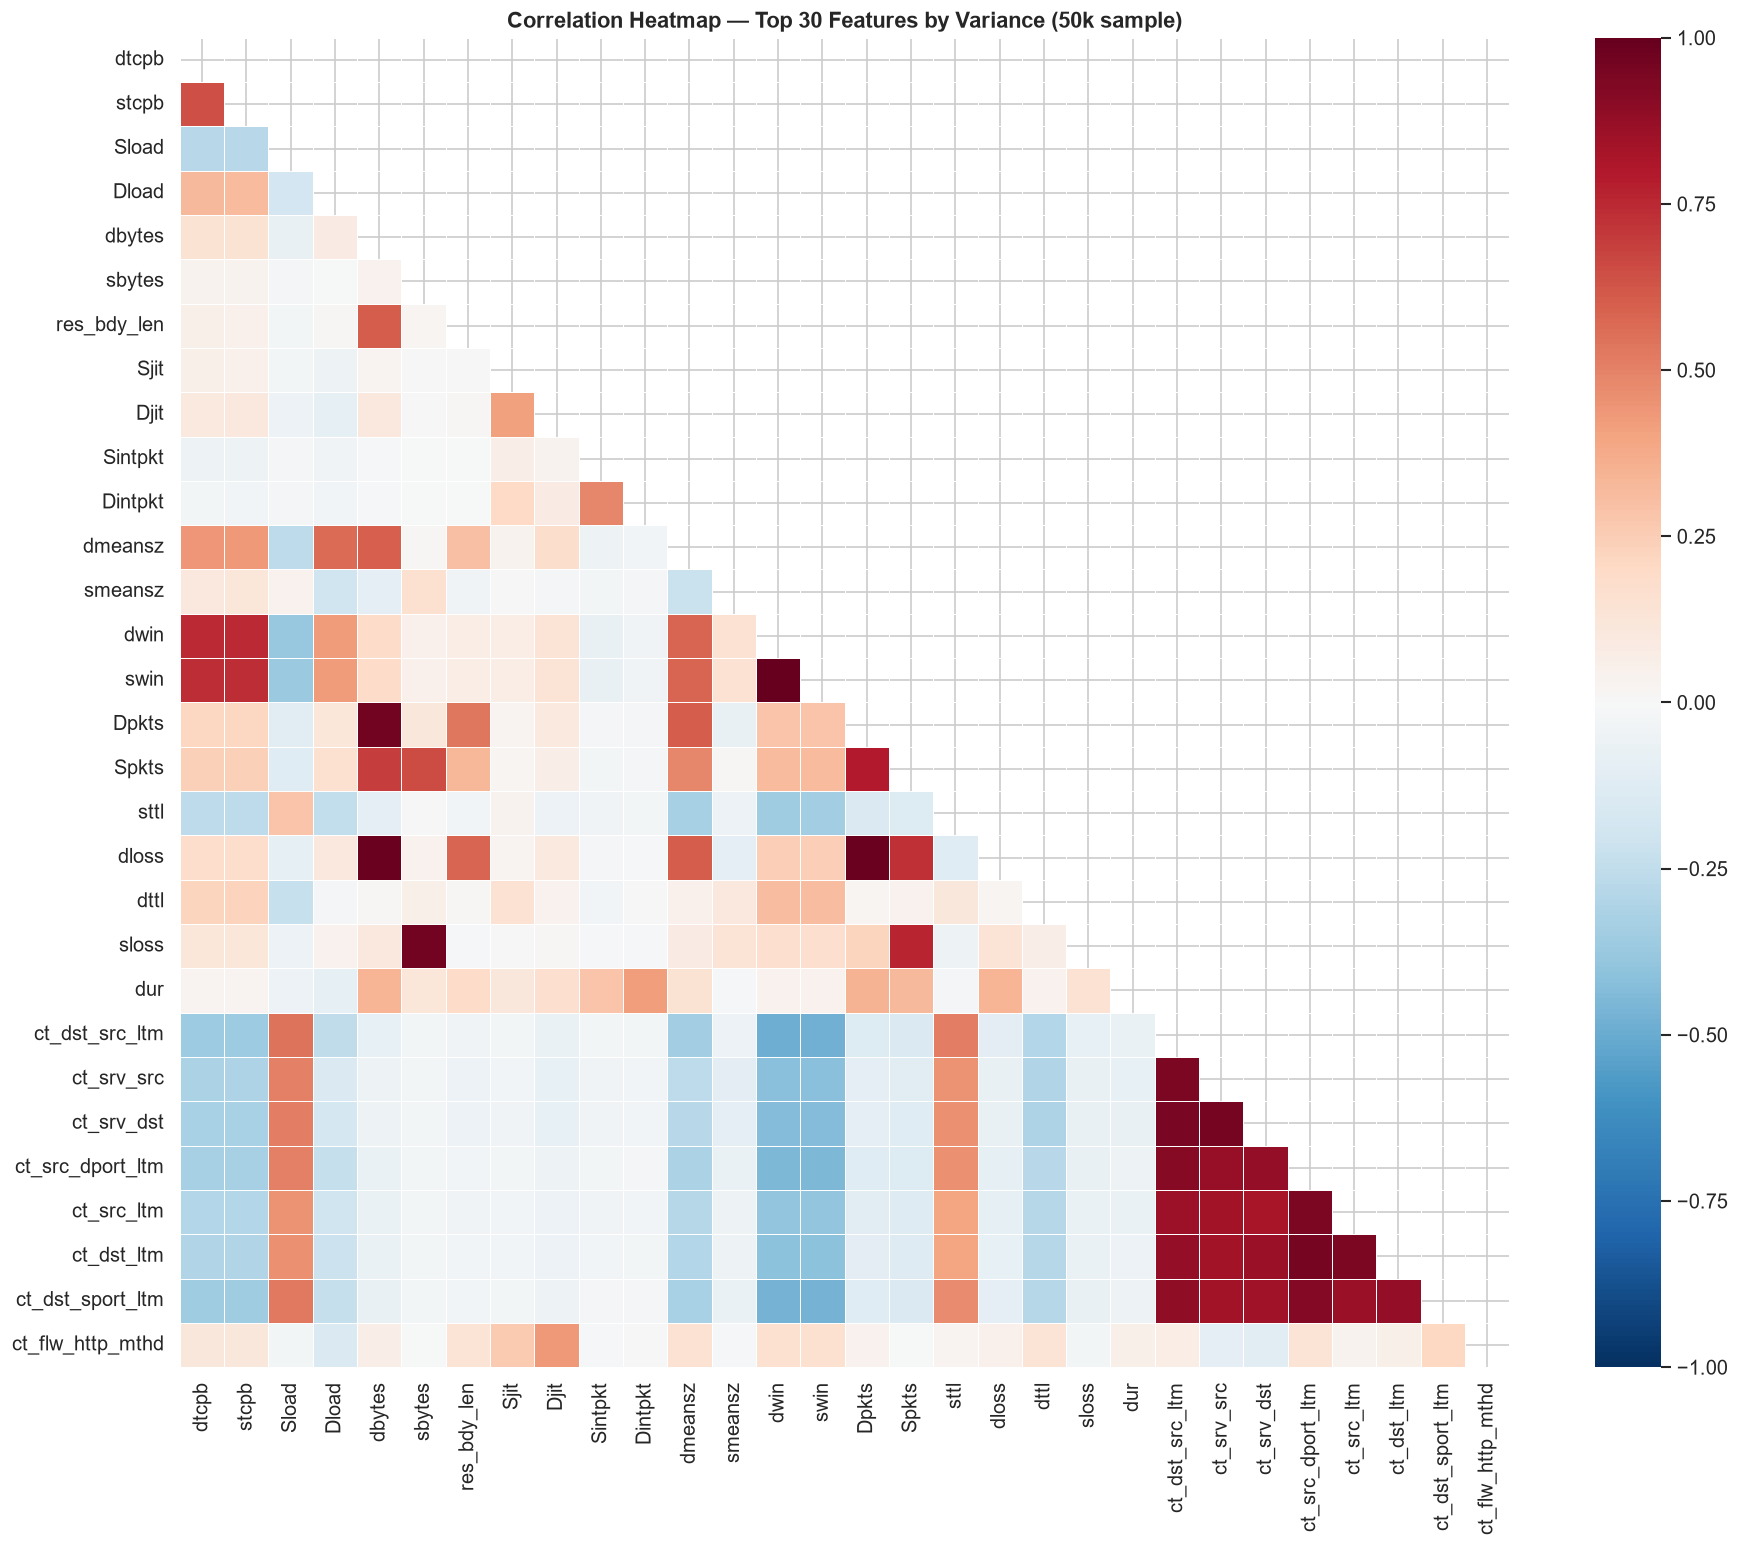

Saved -> correlation_heatmap.png


In [15]:
top_var = df[num_feats].var().nlargest(30).index.tolist()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones(len(top_var), dtype=bool))
sns.heatmap(df[top_var].sample(50_000, random_state=42).corr(),
            mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3, ax=ax)
ax.set_title('Correlation Heatmap — Top 30 Features by Variance (50k sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'correlation_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved -> correlation_heatmap.png')


## 1.4 — Categorical Feature Analysis

In [16]:
for col in ['proto', 'service', 'state']:
    vc = df[col].fillna('-').value_counts()
    print(f'\n=== {col} === ({vc.shape[0]} unique values)')
    print(vc.head(15).to_string())



=== proto === (135 unique values)
proto
tcp       1495074
udp        990435
unas        16202
arp         10064
ospf         7798
sctp         1525
icmp          524
any           411
gre           324
rsvp          274
ipv6          272
sun-nd        262
swipe         262
mobile        262
pim           262

=== service === (13 unique values)
service
-           1246397
dns          781668
http         206273
ftp-data     125783
smtp          81645
ftp           49090
ssh           47160
pop3           1533
dhcp            172
ssl             142
snmp            113
radius           40
irc              31

=== state === (16 unique values)
state
FIN    1478689
CON     560588
INT     490471
REQ       9043
RST        528
ECO        337
CLO        161
URH        108
ACC         43
PAR         30
TST          9
ECR          9
URN          8
no           8
MAS          8


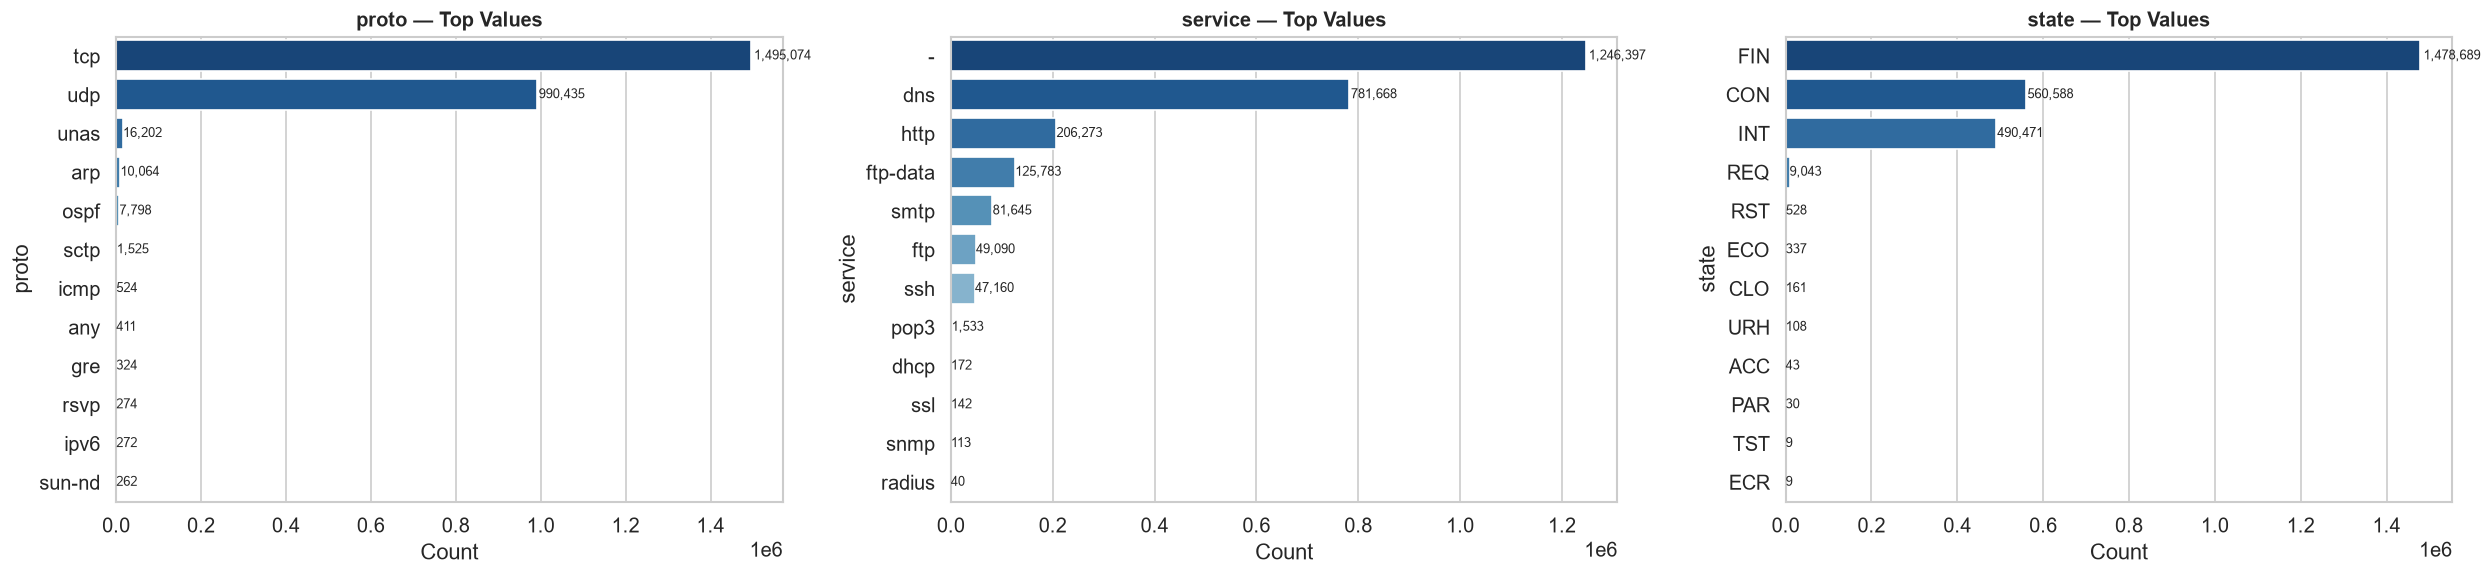

Saved -> categorical_features.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, col in zip(axes, ['proto', 'service', 'state']):
    vc = df[col].fillna('-').value_counts().head(12)
    sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Blues_r', edgecolor='white')
    ax.set_title(f'{col} — Top Values', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(v*1.005, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'categorical_features.png'), bbox_inches='tight')
plt.show()
print('Saved -> categorical_features.png')


## 1.5 — Numerical Feature Distributions (Normal vs Attack)

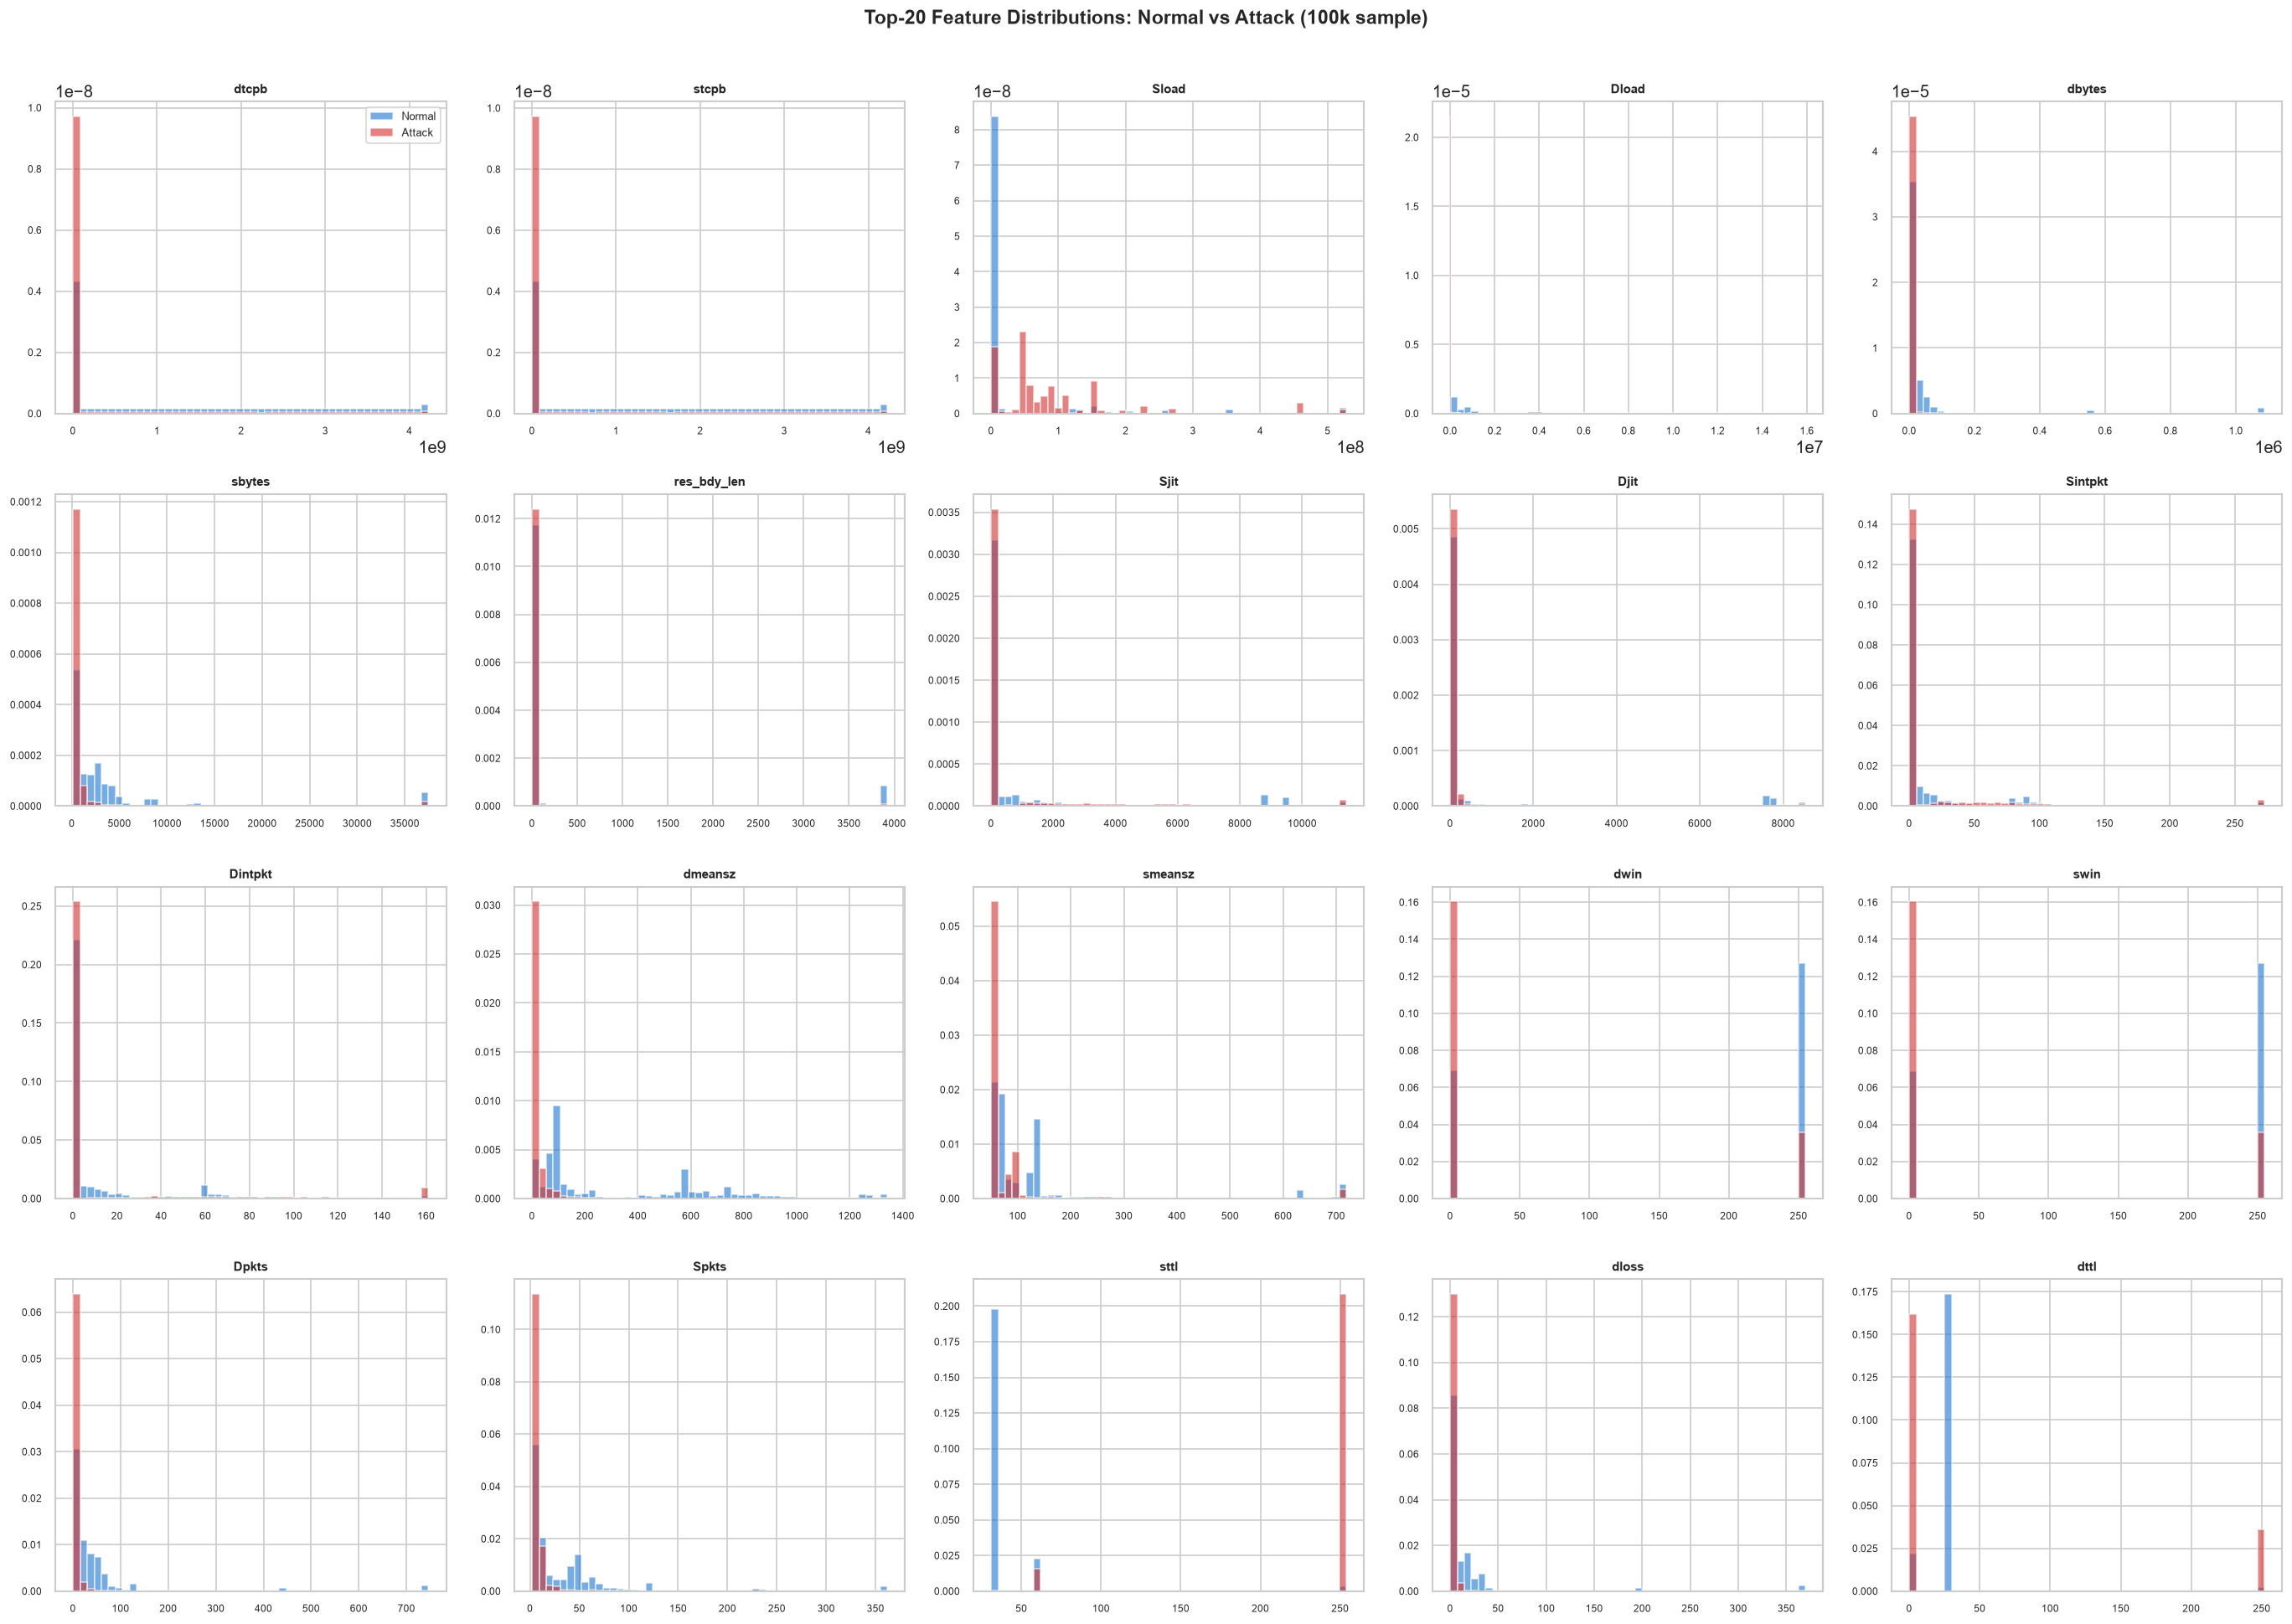

Saved -> feature_histograms.png


In [18]:
# Stratified 100k sample for plotting (plain sample avoids pandas 3.0 groupby key-exclusion)
plot_sample = df.sample(min(len(df), 100_000), random_state=42).reset_index(drop=True)

top20 = df[num_feats].var().nlargest(20).index.tolist()
fig, axes = plt.subplots(4, 5, figsize=(23, 16))
axes = axes.flatten()
for i, col in enumerate(top20):
    ax = axes[i]
    lo = plot_sample[col].quantile(0.01)
    hi = plot_sample[col].quantile(0.99)
    data = plot_sample[col].clip(lo, hi)
    ax.hist(data[plot_sample['label']==0], bins=50, alpha=0.6,
            color='#1976D2', label='Normal', density=True)
    ax.hist(data[plot_sample['label']==1], bins=50, alpha=0.6,
            color='#D32F2F', label='Attack',  density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0: ax.legend(fontsize=8)
plt.suptitle('Top-20 Feature Distributions: Normal vs Attack (100k sample)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'feature_histograms.png'), bbox_inches='tight')
plt.show()
print('Saved -> feature_histograms.png')


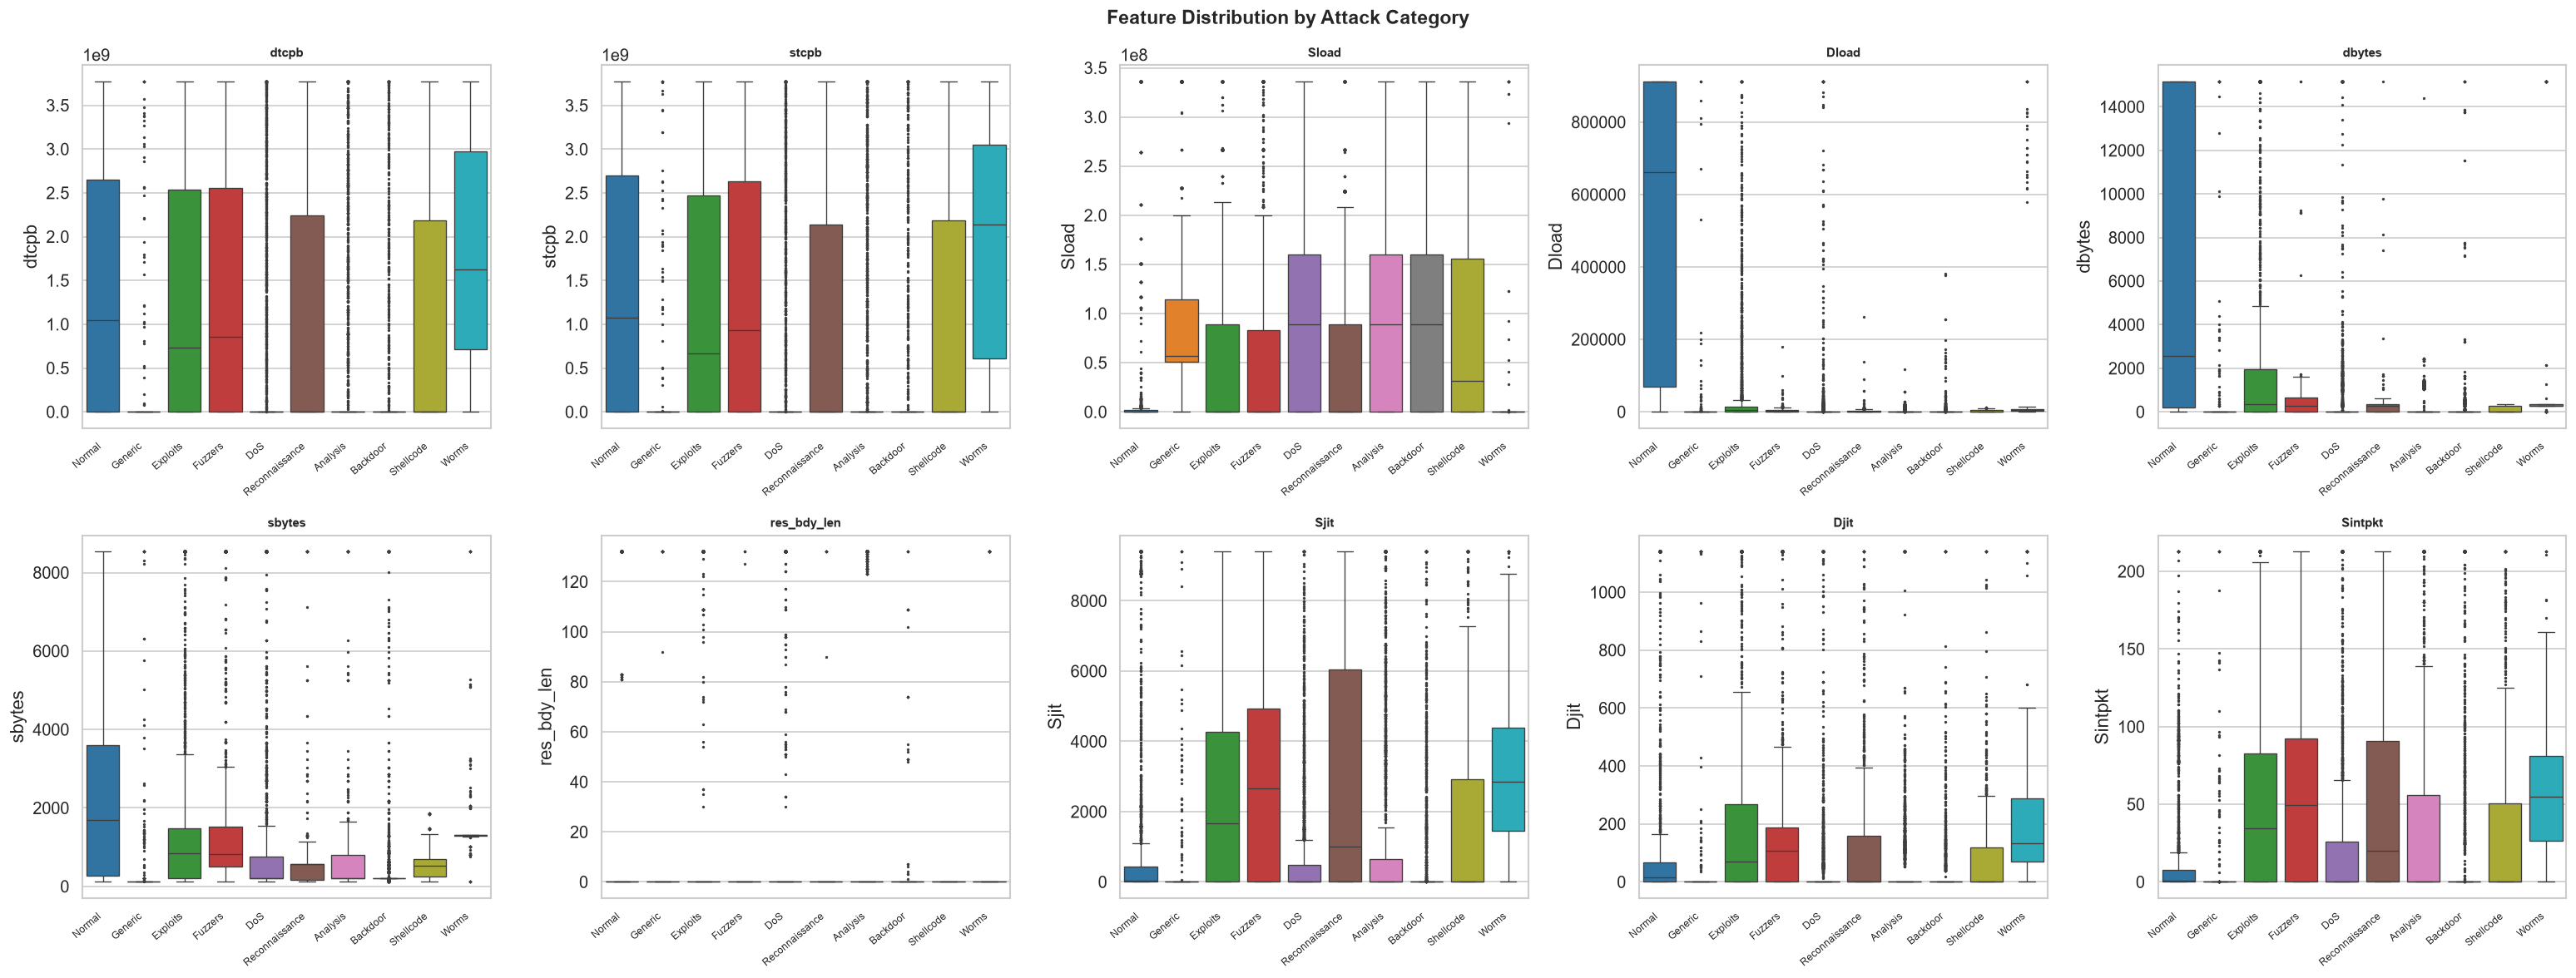

Saved -> boxplots_by_category.png


In [19]:
top10 = df[num_feats].var().nlargest(10).index.tolist()
# pandas 3.0 compatible: use list comprehension instead of groupby().apply()
box_sample = pd.concat([
    g.sample(min(len(g), 3_000), random_state=42)
    for _, g in df.groupby('attack_cat')
], ignore_index=True)
cat_order = df['attack_cat'].value_counts().index.tolist()
fig, axes = plt.subplots(2, 5, figsize=(26, 10))
axes = axes.flatten()
for i, col in enumerate(top10):
    ax = axes[i]
    lo = box_sample[col].quantile(0.05)
    hi = box_sample[col].quantile(0.95)
    bdf = box_sample[[col, 'attack_cat']].copy()
    bdf[col] = bdf[col].clip(lo, hi)
    sns.boxplot(data=bdf, x='attack_cat', y=col, ax=ax,
                order=cat_order, palette='tab10', linewidth=0.8, fliersize=1)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution by Attack Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'boxplots_by_category.png'), bbox_inches='tight')
plt.show()
print('Saved -> boxplots_by_category.png')


## 1.6 — Attack Category Deep-Dive

In [20]:
top_protos = df['proto'].value_counts().head(5).index.tolist()
proto_pivot = (df[df['proto'].isin(top_protos)]
               .groupby(['attack_cat','proto']).size()
               .unstack(fill_value=0)
               .apply(lambda r: r/r.sum() if r.sum()>0 else r, axis=1))
print('Protocol share by attack category:')
print(proto_pivot.round(3).to_string())


Protocol share by attack category:
proto             arp   ospf    tcp    udp   unas
attack_cat                                       
Analysis        0.000  0.046  0.383  0.000  0.571
Backdoor        0.000  0.122  0.244  0.026  0.608
DoS             0.000  0.094  0.332  0.052  0.522
Exploits        0.000  0.041  0.755  0.024  0.180
Fuzzers         0.000  0.009  0.677  0.264  0.050
Generic         0.000  0.001  0.015  0.981  0.003
Normal          0.005  0.002  0.648  0.346  0.000
Reconnaissance  0.000  0.018  0.539  0.378  0.065
Shellcode       0.000  0.000  0.496  0.504  0.000
Worms           0.000  0.000  0.879  0.121  0.000


In [21]:
top_svcs = df['service'].value_counts().head(6).index.tolist()
svc_pivot = (df[df['service'].isin(top_svcs)]
             .groupby(['attack_cat','service']).size()
             .unstack(fill_value=0)
             .apply(lambda r: r/r.sum() if r.sum()>0 else r, axis=1))
print('Service share by attack category:')
print(svc_pivot.round(3).to_string())


Service share by attack category:
service             -    dns    ftp  ftp-data   http   smtp
attack_cat                                                 
Analysis        0.789  0.000  0.000     0.000  0.208  0.002
Backdoor        0.957  0.000  0.003     0.000  0.040  0.000
DoS             0.855  0.009  0.005     0.001  0.106  0.025
Exploits        0.537  0.006  0.049     0.044  0.267  0.097
Fuzzers         0.907  0.015  0.033     0.000  0.045  0.000
Generic         0.016  0.975  0.000     0.000  0.008  0.002
Normal          0.537  0.263  0.021     0.057  0.086  0.035
Reconnaissance  0.847  0.003  0.000     0.000  0.149  0.001
Shellcode       1.000  0.000  0.000     0.000  0.000  0.000
Worms           0.149  0.000  0.000     0.000  0.851  0.000


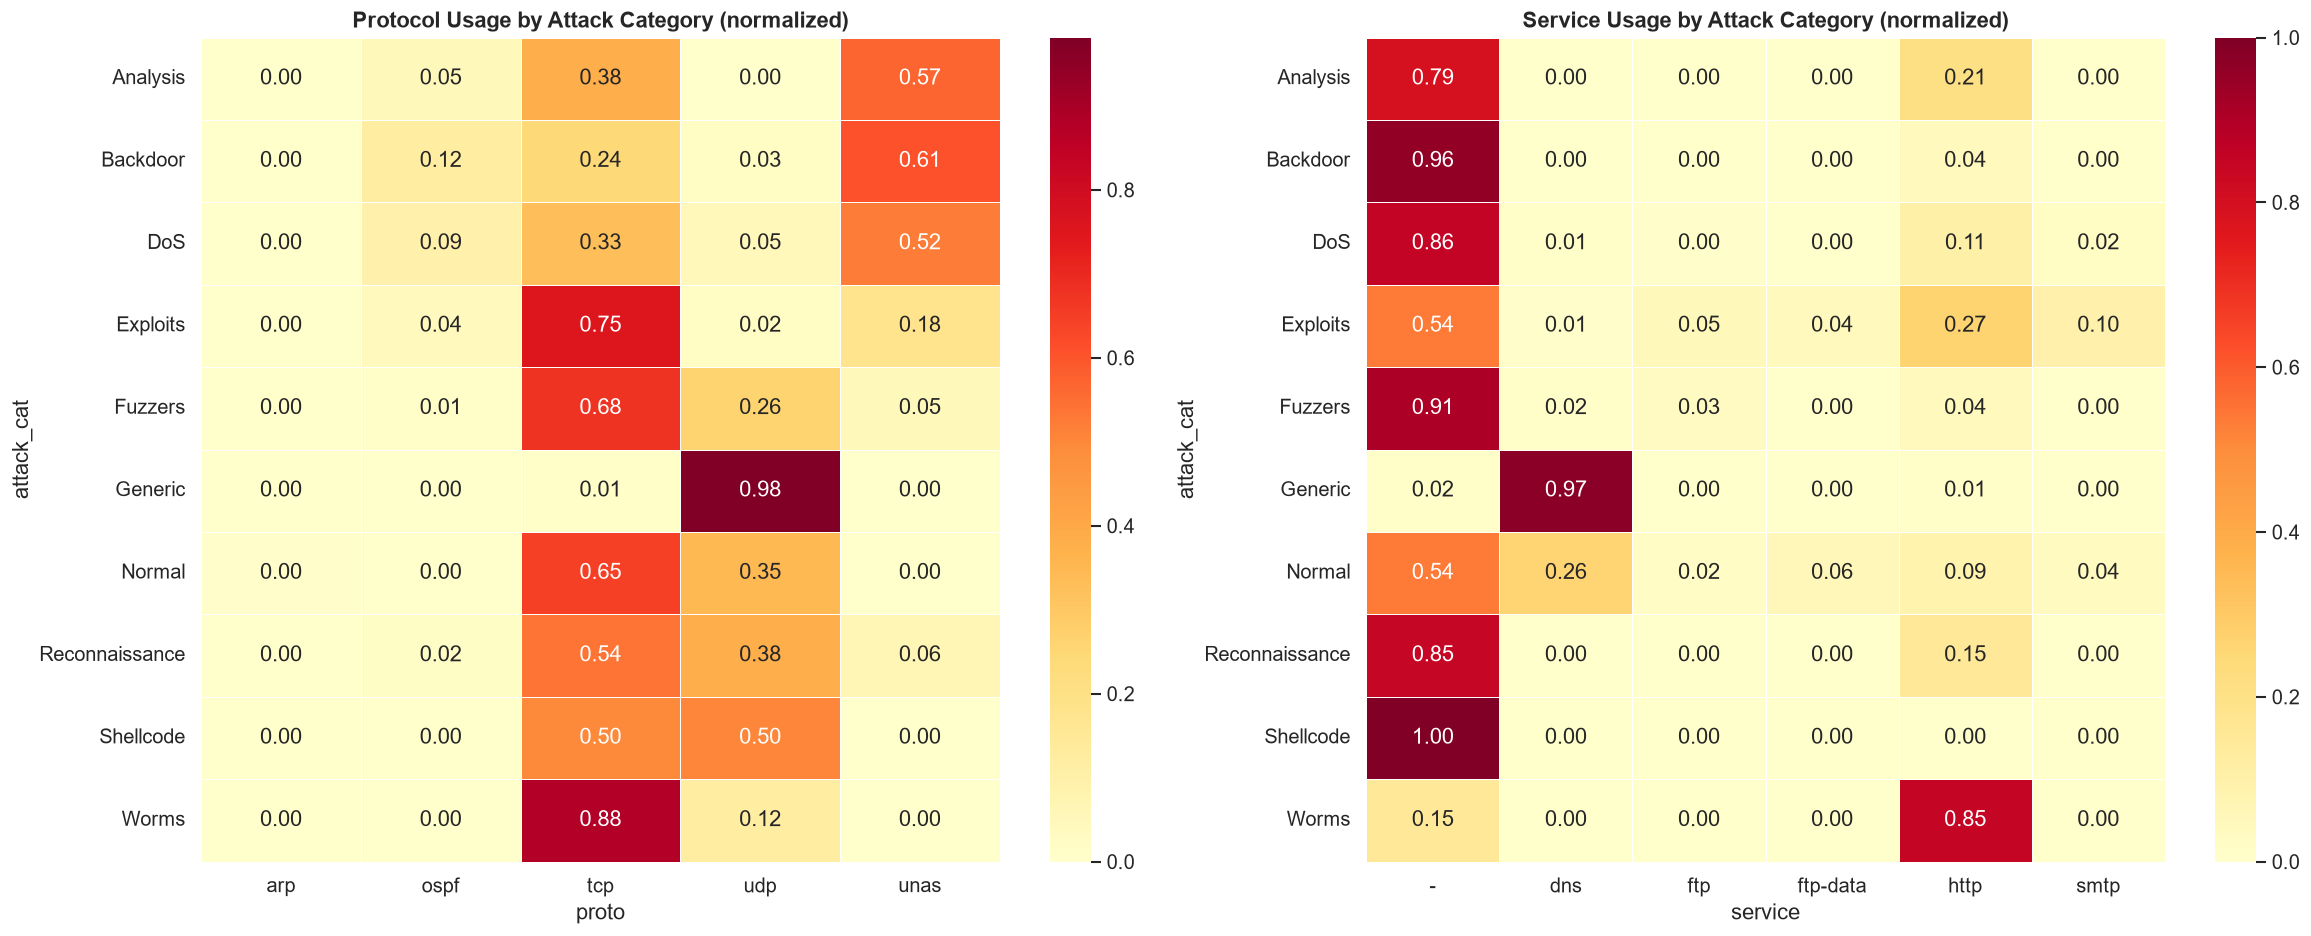

Saved -> attack_cat_heatmaps.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(proto_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Protocol Usage by Attack Category (normalized)', fontweight='bold')
sns.heatmap(svc_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Service Usage by Attack Category (normalized)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'attack_cat_heatmaps.png'), bbox_inches='tight')
plt.show()
print('Saved -> attack_cat_heatmaps.png')


## 1.7 — Temporal Analysis

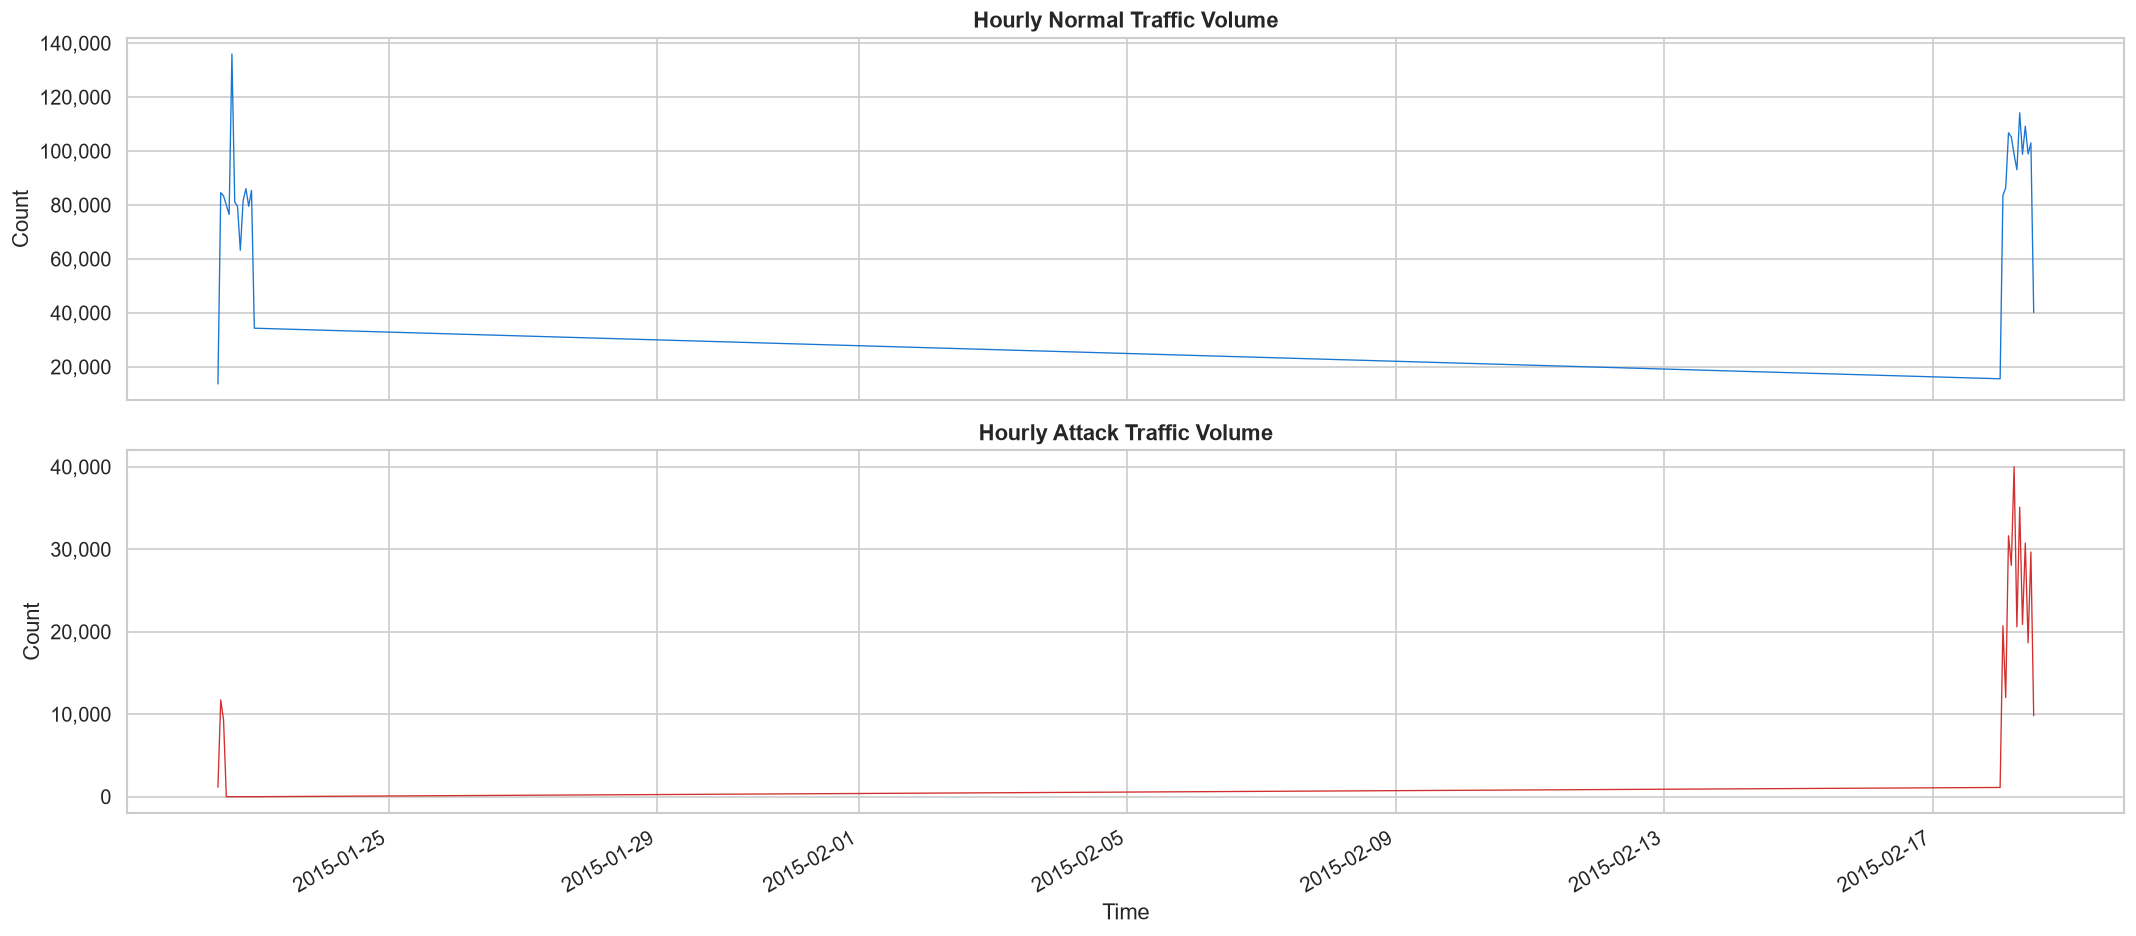

Date range: 2015-01-22 11:49:37 to 2015-02-18 12:21:08
Saved -> temporal_density.png


In [23]:
df['Stime_num'] = pd.to_numeric(df['Stime'], errors='coerce')
df['datetime']  = pd.to_datetime(df['Stime_num'], unit='s', errors='coerce')
df['hour_bin']  = df['datetime'].dt.floor('h')   # pandas 3.0: 'H' renamed to 'h'

hourly = (df.groupby(['hour_bin','label']).size()
           .unstack(fill_value=0)
           .rename(columns={0:'Normal',1:'Attack'})
           .dropna().sort_index())

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
hourly['Normal'].plot(ax=axes[0], color='#1976D2', linewidth=0.8)
axes[0].set_title('Hourly Normal Traffic Volume', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
hourly['Attack'].plot(ax=axes[1], color='#D32F2F', linewidth=0.8)
axes[1].set_title('Hourly Attack Traffic Volume', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Time')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'temporal_density.png'), bbox_inches='tight')
plt.show()
print(f'Date range: {df["datetime"].min()} to {df["datetime"].max()}')
print('Saved -> temporal_density.png')


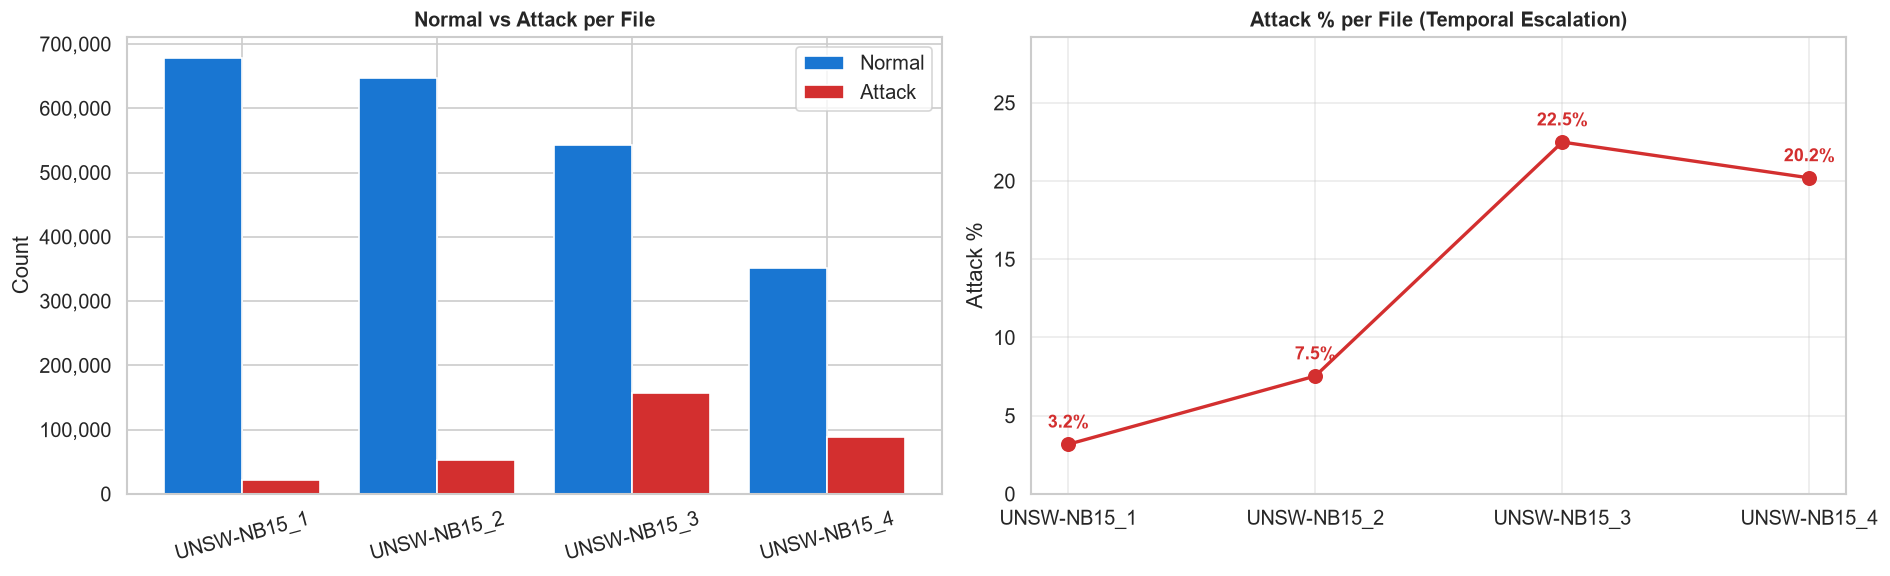

Saved -> per_file_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
files_lbl = [s['file'].replace('.csv','') for s in file_stats]
x = np.arange(len(files_lbl))
w = 0.4
ax = axes[0]
ax.bar(x-w/2, [s['normal'] for s in file_stats], w,
       label='Normal', color='#1976D2', edgecolor='white')
ax.bar(x+w/2, [s['attack'] for s in file_stats], w,
       label='Attack',  color='#D32F2F', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(files_lbl, rotation=15)
ax.set_title('Normal vs Attack per File', fontsize=12, fontweight='bold')
ax.set_ylabel('Count'); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax2 = axes[1]
atk_pct = [s['attack']/s['total']*100 for s in file_stats]
ax2.plot(files_lbl, atk_pct, 'o-', color='#D32F2F', linewidth=2, markersize=8)
for fl, p in zip(files_lbl, atk_pct):
    ax2.annotate(f'{p:.1f}%', (fl, p), textcoords='offset points', xytext=(0,10),
                 ha='center', fontsize=11, fontweight='bold', color='#D32F2F')
ax2.set_title('Attack % per File (Temporal Escalation)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Attack %'); ax2.set_ylim(0, max(atk_pct)*1.3)
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'per_file_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved -> per_file_distribution.png')


## 1.8 — PCA & t-SNE Projection

In [25]:
# Encode categoricals, scale, stratified sample
viz_df = df.copy()
for col in ['proto','service','state']:
    viz_df[col] = LabelEncoder().fit_transform(
        viz_df[col].fillna('-').astype(str))

viz_num = [c for c in NUM_COLS
           if c in viz_df.select_dtypes(include=np.number).columns]
viz_df[viz_num] = viz_df[viz_num].fillna(0)

SAMPLE_N = 6000
n_cats   = viz_df['attack_cat'].nunique()
# pandas 3.0 compatible: use list comprehension instead of groupby().apply()
viz_sample = pd.concat([
    g.sample(min(len(g), SAMPLE_N // n_cats), random_state=42)
    for _, g in viz_df.groupby('attack_cat')
], ignore_index=True)

X_viz = RobustScaler().fit_transform(viz_sample[viz_num])
y_viz = viz_sample['attack_cat'].values
print(f'Viz sample: {X_viz.shape}  categories: {sorted(set(y_viz))}')


Viz sample: (5574, 40)  categories: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


PCA variance explained: 100.0%
Running t-SNE (may take ~1 min)...


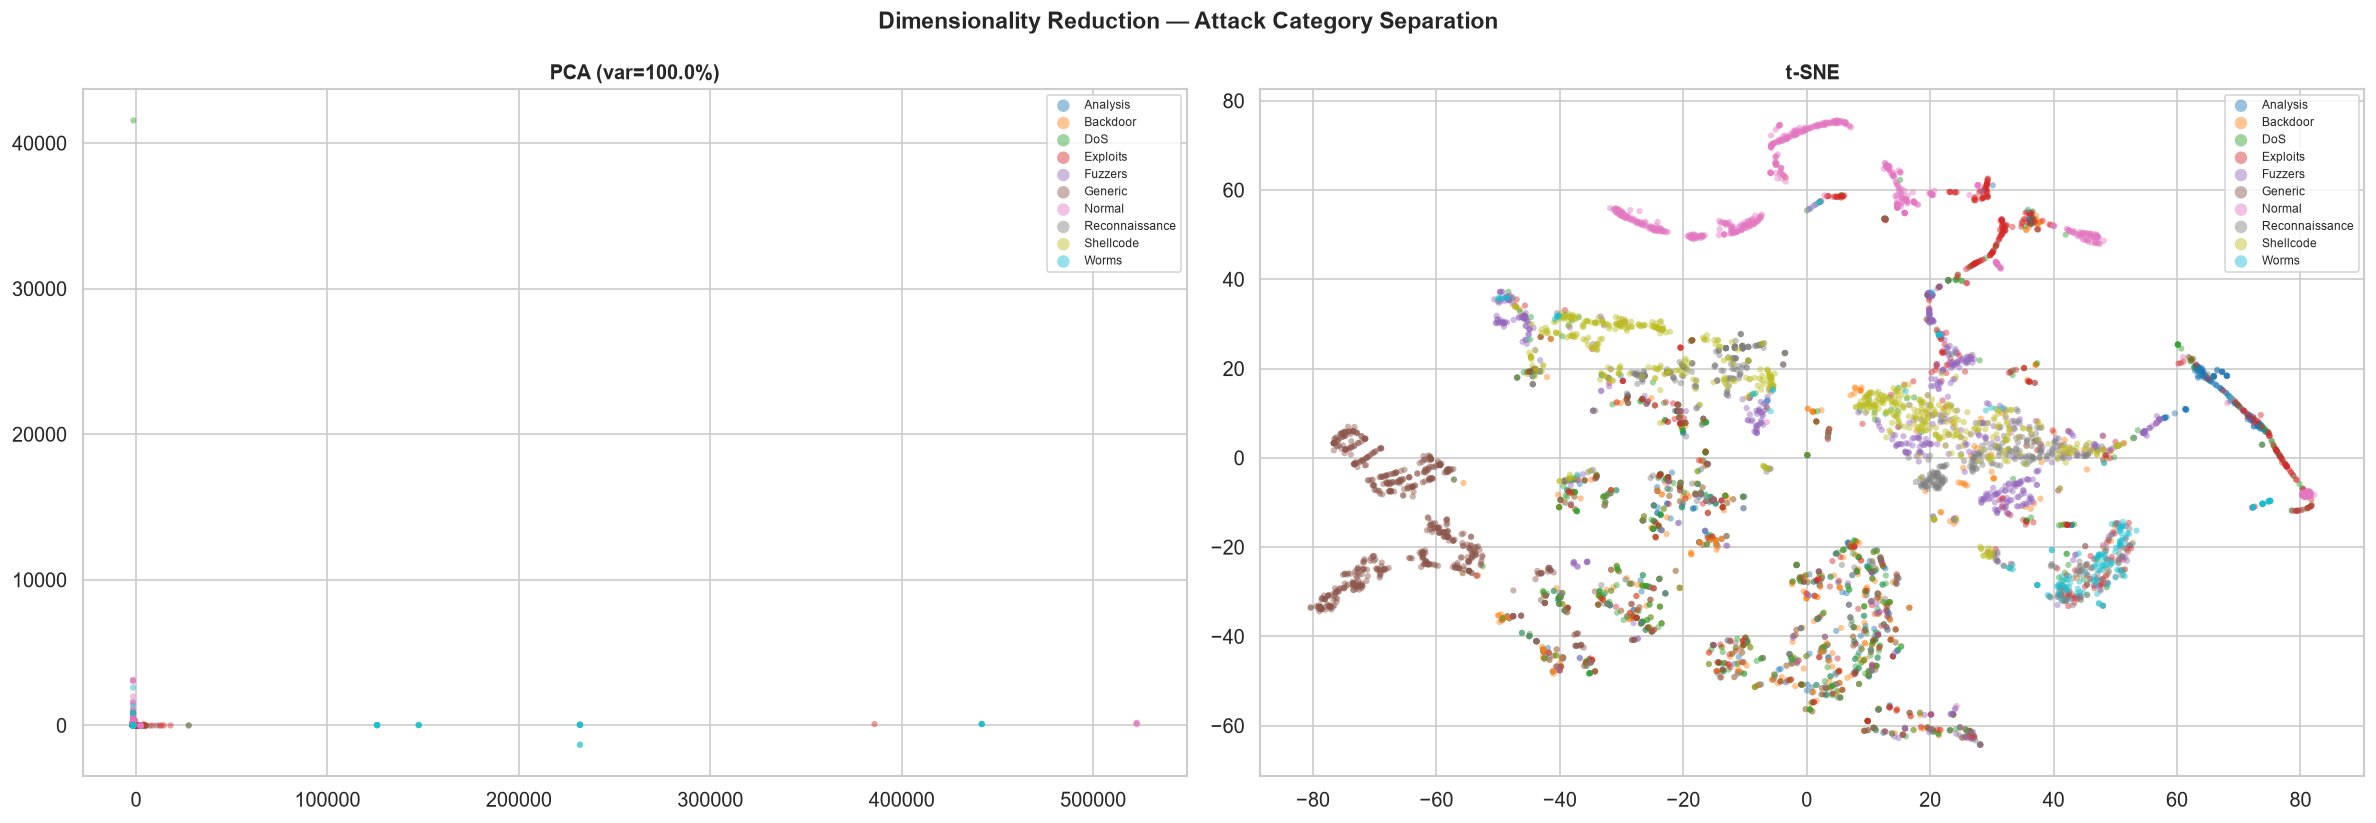

Saved -> pca_tsne.png


In [26]:
categories = sorted(set(y_viz))
palette    = sns.color_palette('tab10', n_colors=len(categories))

pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_viz)
var_exp = pca.explained_variance_ratio_.sum()
print(f'PCA variance explained: {var_exp:.1%}')

print('Running t-SNE (may take ~1 min)...')
tsne   = TSNE(n_components=2, perplexity=40, random_state=42,
              max_iter=1000, learning_rate='auto', init='pca')  # sklearn 1.4+: n_iter -> max_iter
X_tsne = tsne.fit_transform(X_viz)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, X, title in zip(axes,
                        
                         [X_pca, X_tsne],
                         [f'PCA (var={var_exp:.1%})', 't-SNE']):
    for cat, color in zip(categories, palette):
        m = y_viz == cat
        ax.scatter(X[m,0], X[m,1], c=[color], label=cat,
                   alpha=0.45, s=14, edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, markerscale=2)
plt.suptitle('Dimensionality Reduction — Attack Category Separation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'pca_tsne.png'), bbox_inches='tight')
plt.show()
print('Saved -> pca_tsne.png')


## 1.9 — Random Forest Feature Importance

In [27]:
print('Training RF on 100k stratified sample...')
# pandas 3.0 compatible: use list comprehension instead of groupby().apply()
rf_sample = pd.concat([
    g.sample(min(len(g), 50_000), random_state=42)
    for _, g in viz_df.groupby('label')
], ignore_index=True)
X_rf = rf_sample[viz_num].fillna(0).values
y_rf = rf_sample['label'].values

rf = RandomForestClassifier(n_estimators=150, max_depth=12,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)
fi = pd.Series(rf.feature_importances_, index=viz_num).sort_values(ascending=False)
print('\nTop 20 features:')
print(fi.head(20).round(4).to_string())


Training RF on 100k stratified sample...

Top 20 features:
sttl                0.2425
ct_state_ttl        0.2140
Dload               0.0749
dbytes              0.0531
Dintpkt             0.0457
dttl                0.0434
dmeansz             0.0392
state               0.0388
Dpkts               0.0354
smeansz             0.0321
Sload               0.0306
sbytes              0.0276
dur                 0.0221
ackdat              0.0175
tcprtt              0.0157
synack              0.0112
dloss               0.0095
Sintpkt             0.0077
ct_dst_src_ltm      0.0076
ct_dst_sport_ltm    0.0069


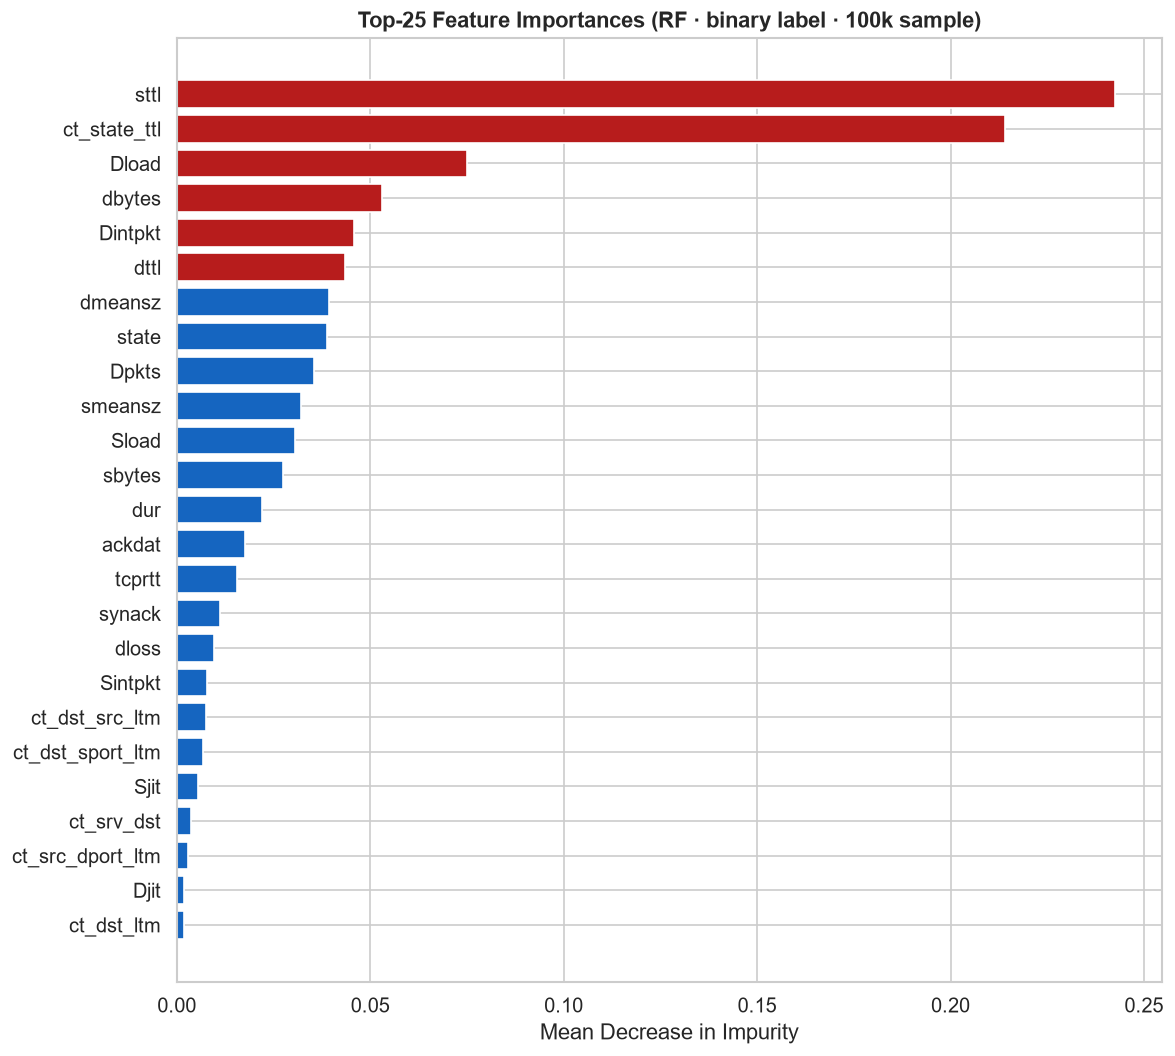

Saved -> rf_feature_importance.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 9))
fi_top  = fi.head(25)
colors  = ['#B71C1C' if v > fi_top.quantile(0.75) else '#1565C0'
            for v in fi_top.values]
ax.barh(fi_top.index[::-1], fi_top.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Top-25 Feature Importances (RF · binary label · 100k sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(os.path.join(OUT_EDA, 'rf_feature_importance.png'), bbox_inches='tight')
plt.show()
print('Saved -> rf_feature_importance.png')


## 1.10 — EDA Summary & Export

In [29]:
summary = {
    'total_records'           : int(len(df)),
    'total_numeric_features'  : len(num_feats),
    'per_file_stats'          : file_stats,
    'binary_label_counts'     : bin_vc.to_dict(),
    'binary_label_pct'        : bin_pct.to_dict(),
    'imbalance_ratio'         : round(float(imb_ratio), 2),
    'attack_cat_counts'       : cat_vc.to_dict(),
    'duplicate_rows'          : int(dups),
    'zero_variance_features'  : zero_var_feats,
    'high_corr_pairs_count'   : int(len(high_corr_df)),
    'high_corr_pairs'         : high_corr_df.to_dict(orient='records'),
    'pca_variance_explained'  : round(float(var_exp), 4),
    'top20_important_features': fi.head(20).index.tolist(),
    'categorical_cardinality' : {c: int(df[c].nunique())
                                  for c in ['proto','service','state']},
    'null_counts'             : df.isnull().sum().to_dict(),
    'date_range'              : {
        'start': str(df['datetime'].min()),
        'end'  : str(df['datetime'].max())
    },
}
with open(os.path.join(OUT_EDA, 'eda_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('='*55)
print('  PHASE 1 EDA — KEY FINDINGS')
print('='*55)
print(f'  Total records          : {len(df):>12,}')
print(f'  Normal flows           : {bin_vc["Normal"]:>12,}  ({bin_pct["Normal"]:.1f}%)')
print(f'  Attack flows           : {bin_vc["Attack"]:>12,}  ({bin_pct["Attack"]:.1f}%)')
print(f'  Imbalance ratio        : {imb_ratio:>12.2f}:1')
print(f'  Attack categories      : {df["attack_cat"].nunique():>12}')
print(f'  Zero-variance features : {len(zero_var_feats):>12}')
print(f'  High-corr pairs (>0.95): {len(high_corr_df):>12}')
print(f'  PCA var explained      : {var_exp:>12.1%}')
print(f'  Top feature (RF)       : {fi.index[0]:>12}')
print(f'  Date range             : {df["datetime"].min().date()} to {df["datetime"].max().date()}')
print('='*55)
plots = sorted([f for f in os.listdir(OUT_EDA) if f.endswith('.png')])
print(f'\nPlots saved ({len(plots)}): {plots}')


  PHASE 1 EDA — KEY FINDINGS
  Total records          :    2,540,047
  Normal flows           :    2,218,764  (87.3%)
  Attack flows           :      321,283  (12.7%)
  Imbalance ratio        :         6.91:1
  Attack categories      :           10
  Zero-variance features :            0
  High-corr pairs (>0.95):            8
  PCA var explained      :       100.0%
  Top feature (RF)       :         sttl
  Date range             : 2015-01-22 to 2015-02-18

Plots saved (10): ['attack_cat_heatmaps.png', 'boxplots_by_category.png', 'categorical_features.png', 'class_dist.png', 'correlation_heatmap.png', 'feature_histograms.png', 'pca_tsne.png', 'per_file_distribution.png', 'rf_feature_importance.png', 'temporal_density.png']
